# Visualizations for Mr.Azrieli

In [17]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [18]:
summary_df = pd.read_csv("output.csv")

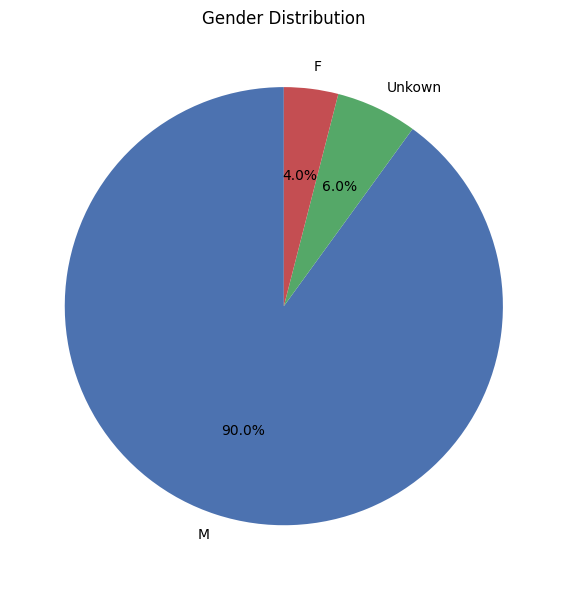

In [19]:
genders = summary_df["Gender"].fillna("Unkown").value_counts()
plt.figure(figsize=(6, 6))
plt.pie(
    genders,
    labels=genders.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Gender Distribution")
plt.tight_layout()
plt.show()




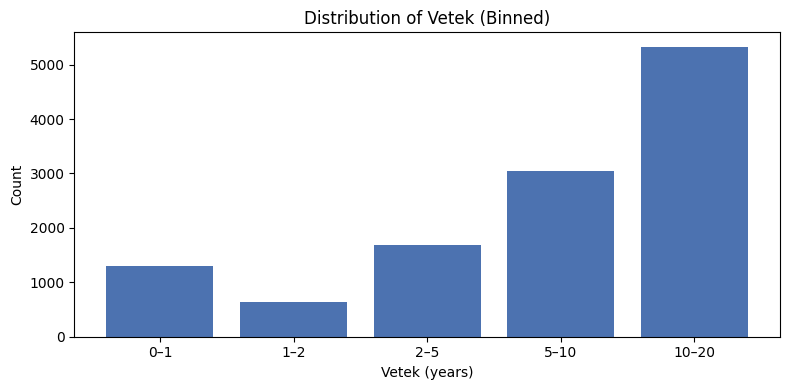

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Define bins (you can change these)
bins = [0, 1, 2, 5, 10, 20]   # example: <1, 1–2, 2–5, 5–10, >10
labels = ["0–1", "1–2", "2–5", "5–10", "10–20"]

summary_df["Vetek_bin"] = pd.cut(summary_df["Vetek"], bins=bins, labels=labels, include_lowest=True)

# Count how many fall in each bin
counts = summary_df["Vetek_bin"].value_counts().sort_index()

# Bar plot
plt.figure(figsize=(8, 4))
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Vetek (years)")
plt.ylabel("Count")
plt.title("Distribution of Vetek (Binned)")
plt.tight_layout()
plt.show()


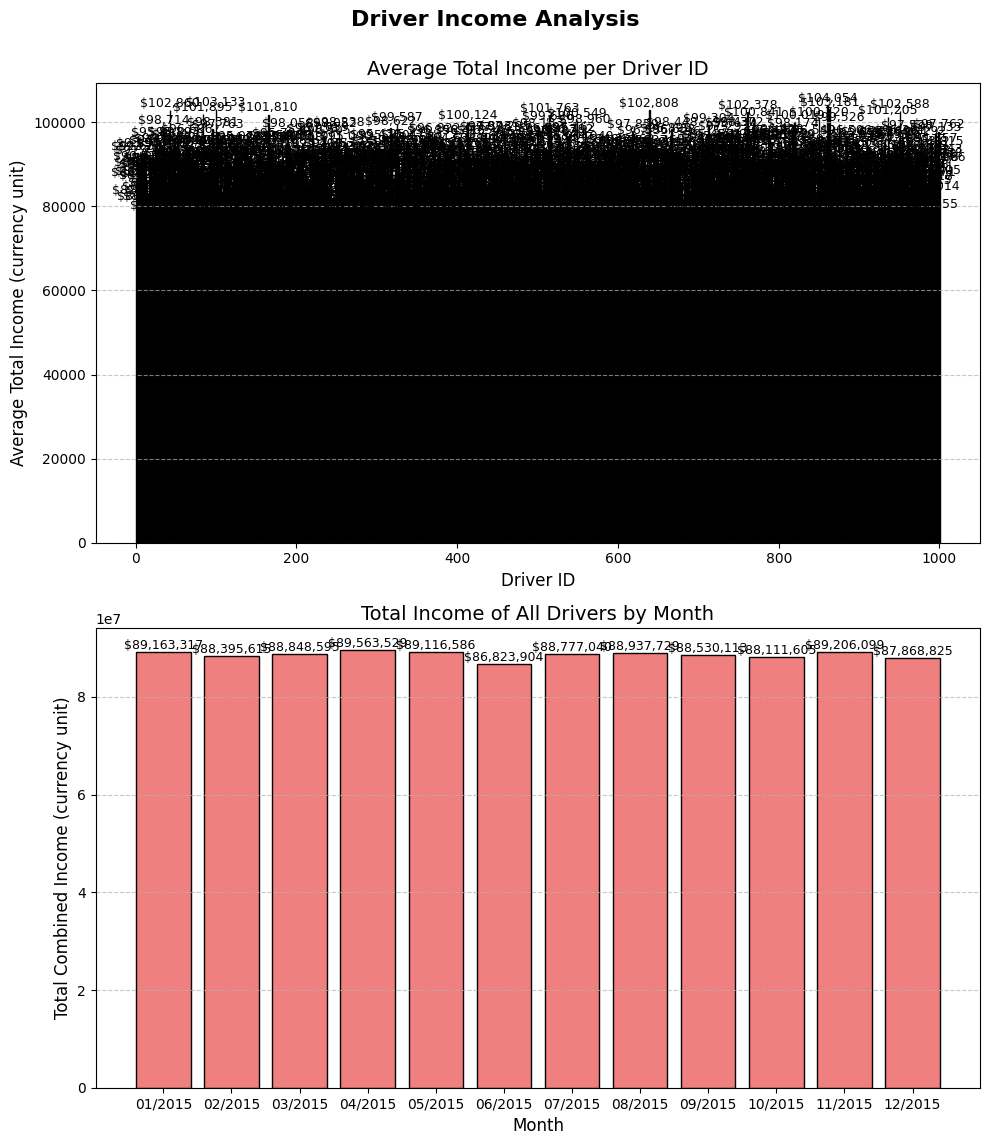

Data processing complete and plots displayed.


In [23]:
avg_income_per_driver = summary_df.groupby('Driver_id')['Total_income'].mean().sort_values(ascending=False)

# b) Calculate Monthly Total Income of All Drivers
# Group by Month and calculate the sum of Total_income for all drivers in that month.
monthly_total_income = summary_df.groupby('Month')['Total_income'].sum()


# --- 3. Plot Generation ---

# Set a professional style for the plots
plt.style.use('seaborn-v0_8-deep')

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 12))
fig.suptitle('Driver Income Analysis', fontsize=16, fontweight='bold')

# --- Plot 1: Average Monthly Total Income per Driver ID ---
ax1 = axes[0]
drivers = avg_income_per_driver.index
incomes = avg_income_per_driver.values
bars1 = ax1.bar(drivers, incomes, color='skyblue', edgecolor='black')

# Adding labels and title for Plot 1
ax1.set_title('Average Total Income per Driver ID', fontsize=14)
ax1.set_xlabel('Driver ID', fontsize=12)
ax1.set_ylabel('Average Total Income (currency unit)', fontsize=12)
ax1.tick_params(axis='x', rotation=0)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Adding value labels on top of the bars
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 50, f'${yval:,.0f}', ha='center', va='bottom', fontsize=9)


# --- Plot 2: Monthly Total Income of All Drivers ---
ax2 = axes[1]
months = monthly_total_income.index.astype(str) # Convert month index to string for plotting
total_incomes = monthly_total_income.values
bars2 = ax2.bar(months, total_incomes, color='lightcoral', edgecolor='black')

# Adding labels and title for Plot 2
ax2.set_title('Total Income of All Drivers by Month', fontsize=14)
ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Total Combined Income (currency unit)', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Adding value labels on top of the bars
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 100, f'${yval:,.0f}', ha='center', va='bottom', fontsize=9)

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

print("Data processing complete and plots displayed.")